In [1]:
from pricing.heston_option_pricing import train_network as train_network_heston, PINN as PINN_heston
from support_tools.testing_tools import heston_2d_slice_test
from support_tools.graphing_tools import plot_convergence, plot_3d_result

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import numpy as np
import matplotlib.pyplot as plt

# Pricing options under Heston model

In [2]:
# setting up a model
pinn = PINN_heston(
    x_min=np.log(0.01),
    x_max=np.log(100.0),
    v_max=0.5,
    T=4.0,
    r_max=0.2,
    kappa_max=5.0,
    theta_max=0.5,
    sigma_max=0.5,
    call_put="Call",
    hidden=75,
    depth=6
).to(device)

In [4]:
# either train the model...
history = train_network_heston(
    pinn=pinn,
    N_pde=4000,
    N_boundary=1000,
    epochs=7000,
    sigma_mode="mean_reverting",
    save_model=True,
    best_model_path=r'trained_models/wide_moneyness_heston.pt',
    lambda_boundary=1.0,
    lambda_terminal=0.5,   
    grad_clip=1.0,
    print_every=100,
    lr=1e-4,               
)

Epoch      1 | Time:       0.22s | LR: 1.000e-04 | Total: 6.538369e+00 | PDE_x: 9.054130e-02 | Terminal_x: 5.726769e-01 | Boundary_x: 6.161489e+00 | GradNorm: 1.374e+02 | Best: 6.538369e+00 @ 1
Epoch    100 | Time:      16.50s | LR: 9.995e-05 | Total: 1.627861e-04 | PDE_x: 5.739774e-05 | Terminal_x: 1.062069e-04 | Boundary_x: 5.228489e-05 | GradNorm: 1.493e-02 | Best: 1.627861e-04 @ 100
Epoch    200 | Time:      33.64s | LR: 9.982e-05 | Total: 4.871692e-05 | PDE_x: 2.169044e-05 | Terminal_x: 1.722365e-05 | Boundary_x: 1.841467e-05 | GradNorm: 1.830e-02 | Best: 4.801140e-05 @ 196
Epoch    300 | Time:      49.84s | LR: 9.959e-05 | Total: 3.777725e-05 | PDE_x: 1.861211e-05 | Terminal_x: 1.435216e-05 | Boundary_x: 1.198907e-05 | GradNorm: 1.262e-02 | Best: 3.736386e-05 @ 299
Epoch    400 | Time:      65.80s | LR: 9.928e-05 | Total: 2.899613e-05 | PDE_x: 1.545878e-05 | Terminal_x: 9.165410e-06 | Boundary_x: 8.954641e-06 | GradNorm: 1.280e-02 | Best: 2.899613e-05 @ 400
Epoch    500 | Time:  

In [10]:
# ...or load the saved ones
state_dict = torch.load(r'trained_models/heston.pt', weights_only=True)['model_state_dict']
pinn.load_state_dict(state_dict)
pinn.eval()

PINN(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=75, bias=True)
    (1): Tanh()
    (2): Linear(in_features=75, out_features=75, bias=True)
    (3): Tanh()
    (4): Linear(in_features=75, out_features=75, bias=True)
    (5): Tanh()
    (6): Linear(in_features=75, out_features=75, bias=True)
    (7): Tanh()
    (8): Linear(in_features=75, out_features=75, bias=True)
    (9): Tanh()
    (10): Linear(in_features=75, out_features=75, bias=True)
    (11): Tanh()
    (12): Linear(in_features=75, out_features=1, bias=True)
  )
)

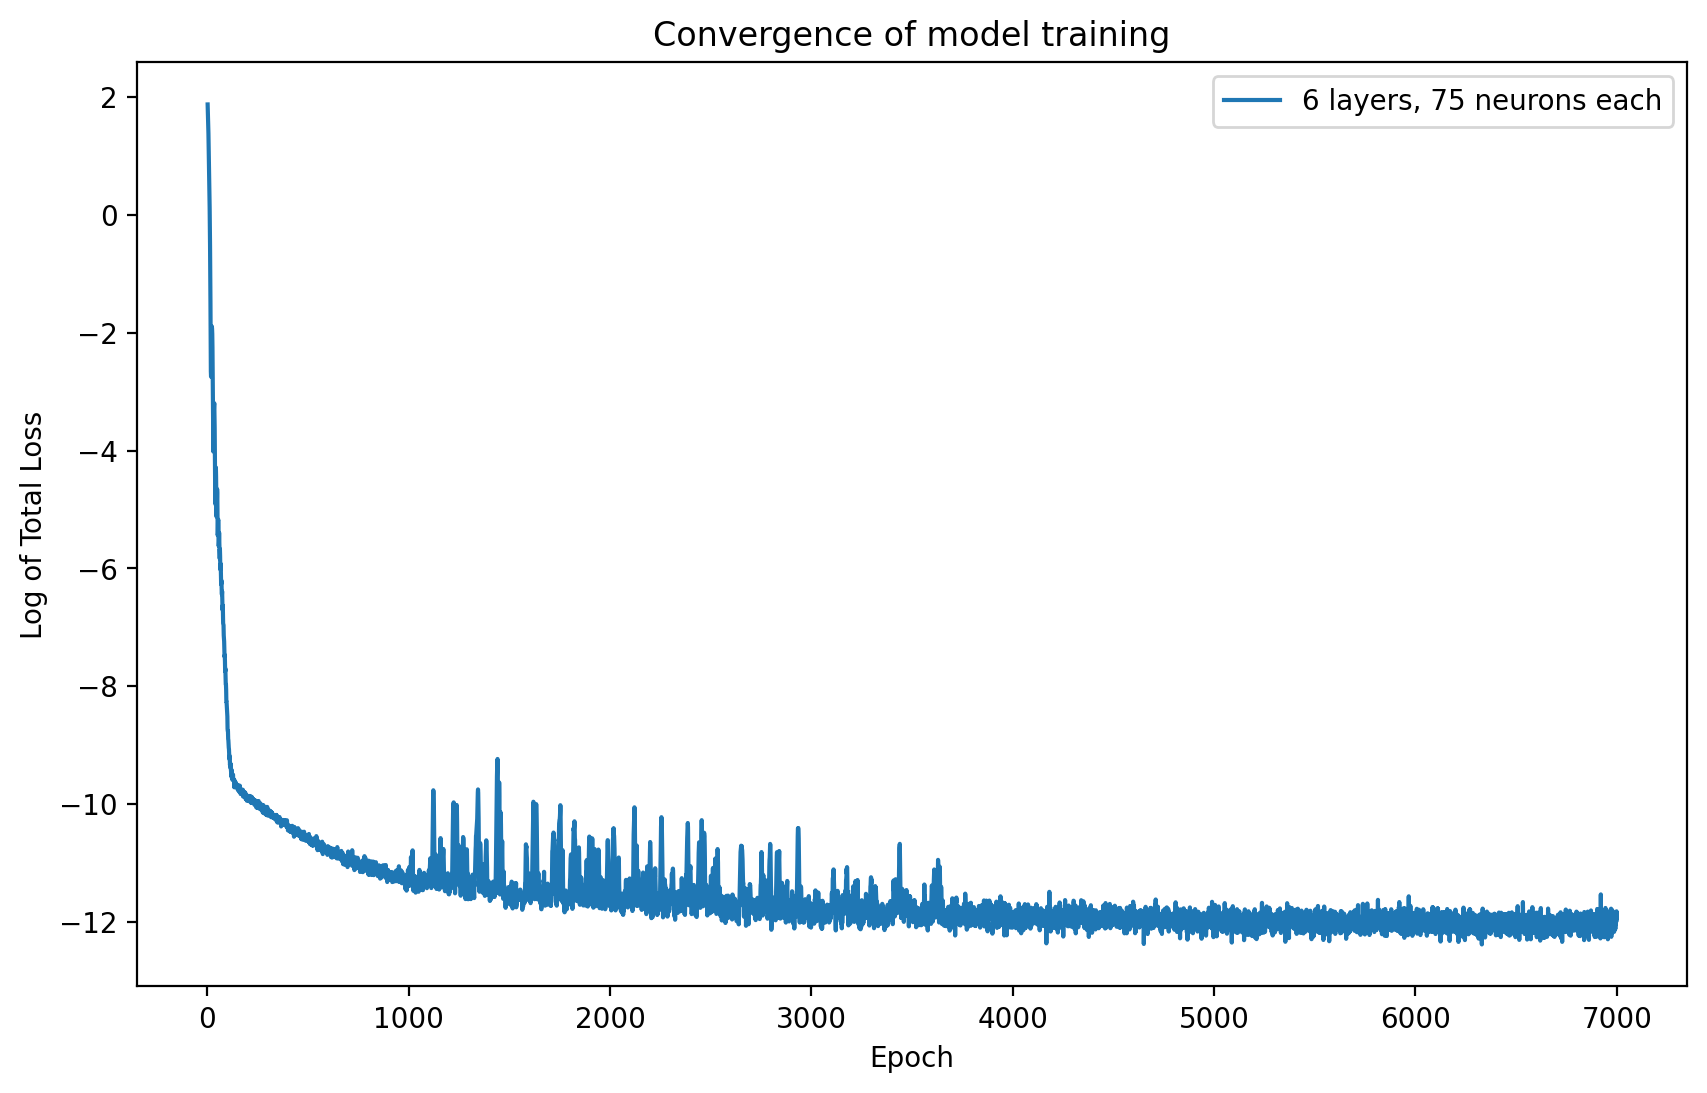

In [7]:
plot_convergence(history, x_axis = 'epochs')

In [11]:
# test the accuracy of the model against quasi-analytical pricing
results = heston_2d_slice_test(pinn = pinn, return_values = True)

MSE = 0.011344795872346212
RMSE = 0.10651195178169542
MAE = 0.07300287370248465


In [12]:
plot_3d_result(results, 'diff')

In [11]:
# testing multiple models
pinn_5_50 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=50, depth=5).to(device)
pinn_6_75 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=75, depth=6).to(device)
pinn_7_100 = PINN_heston(x_min=np.log(0.01), x_max=np.log(15.0), v_max=0.5, T=4.0, r_max=0.2, kappa_max=5.0, theta_max=0.5, sigma_max=0.5, call_put="Call",
    hidden=100, depth=7).to(device)

pinns = [pinn_5_50, pinn_6_75, pinn_7_100]
histories = []

for pinn in pinns:
    histories.append(train_network_heston(
        pinn=pinn,
        N_pde=4000,
        N_boundary=1000,
        epochs=7000,
        sigma_mode="mean_reverting",
        save_model=False, 
        lambda_boundary=1.0,
        lambda_terminal=0.5,   
        grad_clip=1.0,
        print_every=1000,
        lr=1e-4,               
    ))

Epoch      1 | Time:       0.61s | LR: 1.000e-04 | Total: 4.599185e+00 | PDE_x: 9.485729e-02 | Terminal_x: 4.647983e-01 | Boundary_x: 4.271929e+00 | GradNorm: 1.130e+02 | Best: 4.599185e+00 @ 1
Epoch   1000 | Time:      82.76s | LR: 9.554e-05 | Total: 2.375489e-05 | PDE_x: 1.401189e-05 | Terminal_x: 3.125317e-06 | Boundary_x: 8.180342e-06 | GradNorm: 2.734e-02 | Best: 2.250206e-05 @ 992
Epoch   2000 | Time:     165.61s | LR: 8.306e-05 | Total: 1.187432e-05 | PDE_x: 8.962159e-06 | Terminal_x: 1.094568e-06 | Boundary_x: 2.364880e-06 | GradNorm: 2.430e-02 | Best: 1.084282e-05 @ 1968
Epoch   3000 | Time:     247.36s | LR: 6.501e-05 | Total: 1.075602e-05 | PDE_x: 8.352335e-06 | Terminal_x: 5.239861e-07 | Boundary_x: 2.141687e-06 | GradNorm: 4.295e-02 | Best: 8.136423e-06 @ 2932
Epoch   4000 | Time:     329.34s | LR: 4.499e-05 | Total: 7.033840e-06 | PDE_x: 5.742518e-06 | Terminal_x: 3.743230e-07 | Boundary_x: 1.104161e-06 | GradNorm: 2.866e-02 | Best: 6.912393e-06 @ 3766
Epoch   5000 | Time

In [ ]:
plot_convergence(histories, x_axis = 'epochs')